# Sentinel-2 image and rasters processing notebook

**Description**

This notebook is used for processing Sentinel-2 images including calculating indices and stack all rasters together. The stacked image is used as an input of deep learning model in later step.

Main steps of Sentinel-2 image and rasters processing:
1. Import data
2. Calculate indices (NDVI, NDWI, and NDBI)
3. Stack Sentinel-2 image, PUGS binary mask, and PUGS SDT raster together

*PUGS = public urban green space, SDT = signed-distance transform*

**Input files**
3 raster files
- sentinel2_openeo_med_4months_dresden.geotiff
- public_green_spaces_dresden.geotiff
- sdt_public_green_spaces_dresden.geotiff

**Output files**

1 geotiff file
- stacked_sentinel2_dresden.geotiff

**Requirements/Dependencies**

This notebook requires user to run *1_data_acquisition_satellite_image.ipynb*, *1_data_acquisition_osm.ipynb*, and *2_data_processing_osm.ipynb* first.

# Import libraries

In [13]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(root_dir)

In [14]:
import rioxarray
import matplotlib.pyplot as plt
import xarray as xr
import pugs_detection.utils as utils

# Import Sentinel-2 image

In [15]:
file_path = '../data/raw/sentinel-2/sentinel2_openeo_med_4months_dresden.geotiff'
data = rioxarray.open_rasterio(file_path)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as 

In [16]:
processed_sat_img = utils.contrast_stretch(data)

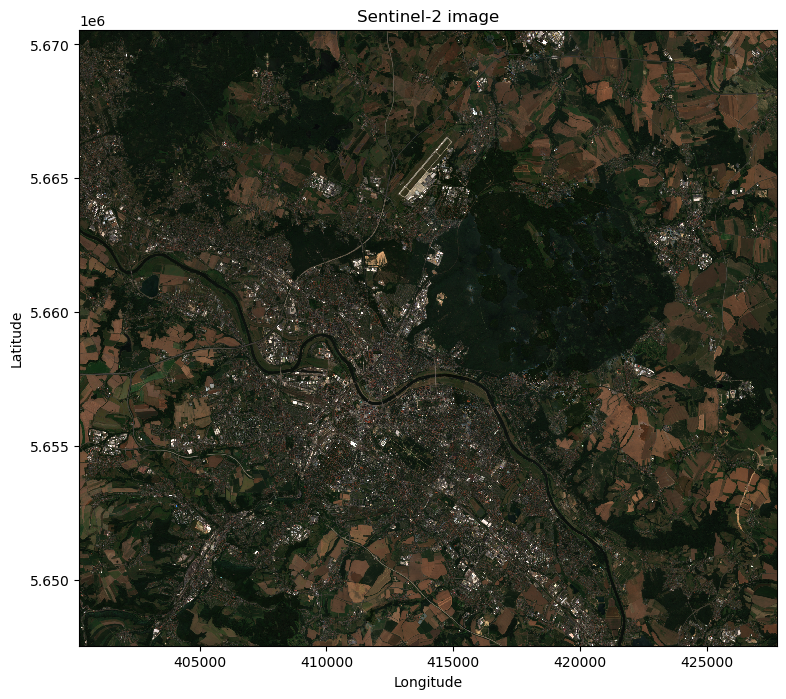

In [17]:
# Plot the raster data
plt.figure(figsize=(9,8))
processed_sat_img.sel(band=[4, 3, 2]).plot.imshow()
plt.title("Sentinel-2 image")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [18]:
processed_sat_img

<xarray.DataArray (band: 13, y: 2301, x: 2747)> Size: 657MB
array([[[5.45761893e-02, 5.45761893e-02, 5.45761893e-02, ...,
         1.04805603e-01, 1.04805603e-01, 1.04805603e-01],
        [5.26442888e-02, 5.26442888e-02, 5.26442888e-02, ...,
         1.14706593e-01, 1.14706593e-01, 1.14706593e-01],
        [5.26442888e-02, 5.26442888e-02, 5.26442888e-02, ...,
         1.14706593e-01, 1.14706593e-01, 1.14706593e-01],
        ...,
        [4.80560251e-02, 4.80560251e-02, 4.80560251e-02, ...,
         7.17218063e-02, 7.17218063e-02, 7.17218063e-02],
        [4.20188360e-02, 4.20188360e-02, 4.20188360e-02, ...,
         7.55856073e-02, 7.55856073e-02, 7.55856073e-02],
        [4.20188360e-02, 4.20188360e-02, 4.20188360e-02, ...,
         7.55856073e-02, 7.55856073e-02, 7.55856073e-02]],

       [[5.04709007e-02, 5.07123883e-02, 4.92634629e-02, ...,
         9.75609756e-02, 1.09152379e-01, 1.15431055e-01],
        [5.19198261e-02, 5.60251147e-02, 5.69910650e-02, ...,
         1.20019319e-01, 1.10359816e-01, 1.10842792e-01],
        [4.80560251e-02, 5.40932142e-02, 5.38517266e-02, ...,
         1.29678822e-01, 1.26780971e-01, 1.21468244e-01],
...
        [1.51895677e-01, 1.51895677e-01, 1.40787249e-01, ...,
         3.45327216e-01, 3.45327216e-01, 3.63438783e-01],
        [1.48514851e-01, 1.48514851e-01, 1.32093697e-01, ...,
         2.82781937e-01, 2.82781937e-01, 3.61506882e-01],
        [1.48514851e-01, 1.48514851e-01, 1.32093697e-01, ...,
         2.82781937e-01, 2.82781937e-01, 3.61506882e-01]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 2.41487563e-04],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 2.41487563e-04],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 2.41487563e-04]]])
Coordinates:
  * band         (band) int64 104B 1 2 3 4 5 6 7 8 9 10 11 12 13
  * x            (x) float64 22kB 4.003e+05 4.003e+05 ... 4.277e+05 4.277e+05
  * y            (y) float64 18kB 5.671e+06 5.671e+06 ... 5.648e+06 5.648e+06
    spatial_ref  int64 8B 0

# Import binary mask and SDT raster

In [19]:
file_path = '../data/processed/osm/public_green_spaces_dresden.geotiff'
binary_mask_pugs = rioxarray.open_rasterio(file_path)

In [20]:
binary_mask_pugs = binary_mask_pugs.assign_coords(band=[14])
binary_mask_pugs

<xarray.DataArray (band: 1, y: 2301, x: 2747)> Size: 6MB
[6320847 values with dtype=uint8]
Coordinates:
  * x            (x) float64 22kB 4.003e+05 4.003e+05 ... 4.277e+05 4.277e+05
  * y            (y) float64 18kB 5.671e+06 5.671e+06 ... 5.648e+06 5.648e+06
    spatial_ref  int64 8B 0
  * band         (band) int64 8B 14
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        1
    STATISTICS_MEAN:           0.23659576681055
    STATISTICS_MINIMUM:        0
    STATISTICS_STDDEV:         0.42499201161654
    STATISTICS_VALID_PERCENT:  100
    scale_factor:              1.0
    add_offset:                0.0

In [21]:
file_path = '../data/processed/osm/sdt_public_green_spaces_dresden.geotiff'
sdt_pugs = rioxarray.open_rasterio(file_path)

In [22]:
sdt_pugs = sdt_pugs.assign_coords(band=[15])
sdt_pugs

<xarray.DataArray (band: 1, y: 2301, x: 2747)> Size: 51MB
[6320847 values with dtype=float64]
Coordinates:
  * x            (x) float64 22kB 4.003e+05 4.003e+05 ... 4.277e+05 4.277e+05
  * y            (y) float64 18kB 5.671e+06 5.671e+06 ... 5.648e+06 5.648e+06
    spatial_ref  int64 8B 0
  * band         (band) int64 8B 15
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

# Calculate NDVI

<xarray.DataArray ()> Size: 8B
array(1.)
Coordinates:
    spatial_ref  int64 8B 0 <xarray.DataArray ()> Size: 8B
array(-0.51552795)
Coordinates:
    spatial_ref  int64 8B 0


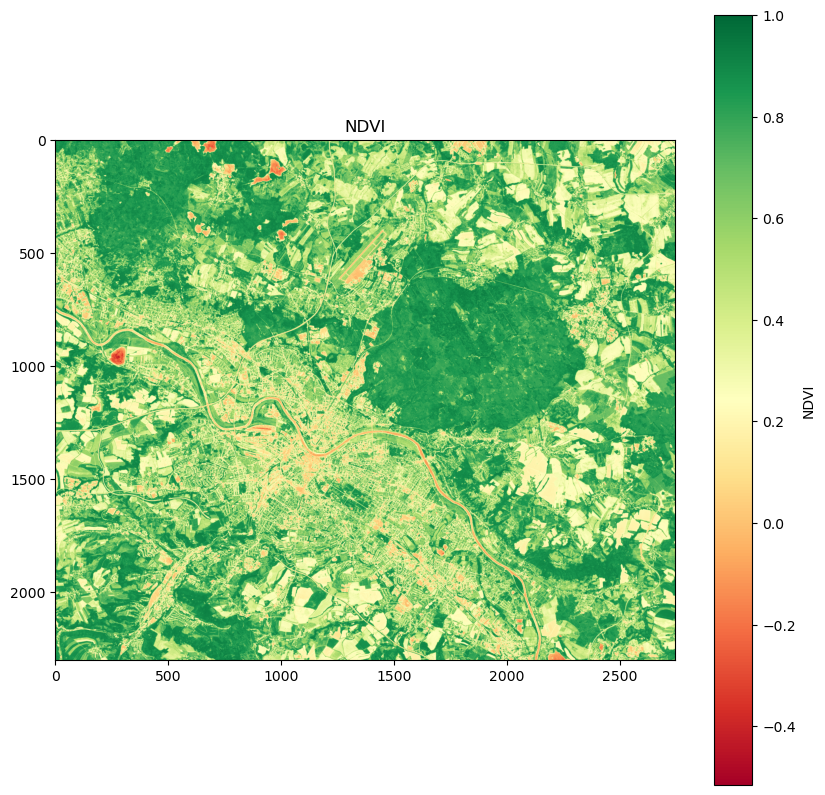

In [23]:
red = processed_sat_img.sel(band=4)
nir = processed_sat_img.sel(band=8)

# Calculate NDVI
ndvi = (nir - red) / (nir + red)
ndvi = ndvi.expand_dims('band').assign_coords(band=[16])

print(ndvi.max(), ndvi.min())

# Plot the NDVI
plt.figure(figsize=(10, 10))
plt.imshow(ndvi.sel(band=16), cmap='RdYlGn')
plt.colorbar(label='NDVI')
plt.title('NDVI')
plt.show()

# Calculate NDWI

<xarray.DataArray ()> Size: 8B
array(0.79047619)
Coordinates:
    spatial_ref  int64 8B 0 <xarray.DataArray ()> Size: 8B
array(-1.)
Coordinates:
    spatial_ref  int64 8B 0


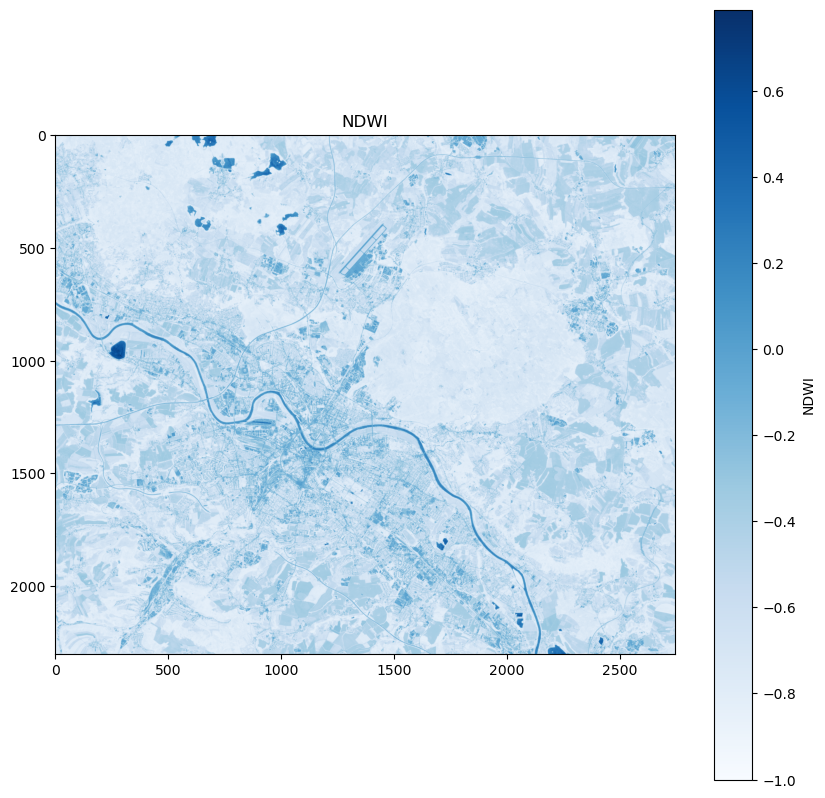

In [24]:
green = processed_sat_img.sel(band=3)

# Calculate NDWI
ndwi = (green - nir) / (green + nir)
ndwi = ndwi.expand_dims('band').assign_coords(band=[17])

print(ndwi.max(), ndwi.min())

# Plot the NDWI
plt.figure(figsize=(10, 10))
plt.imshow(ndwi.sel(band=17), cmap='Blues')
plt.colorbar(label='NDWI')
plt.title('NDWI')
plt.show()

# Calculate NDBI

<xarray.DataArray ()> Size: 8B
array(0.68910891)
Coordinates:
    spatial_ref  int64 8B 0 <xarray.DataArray ()> Size: 8B
array(-0.82942097)
Coordinates:
    spatial_ref  int64 8B 0


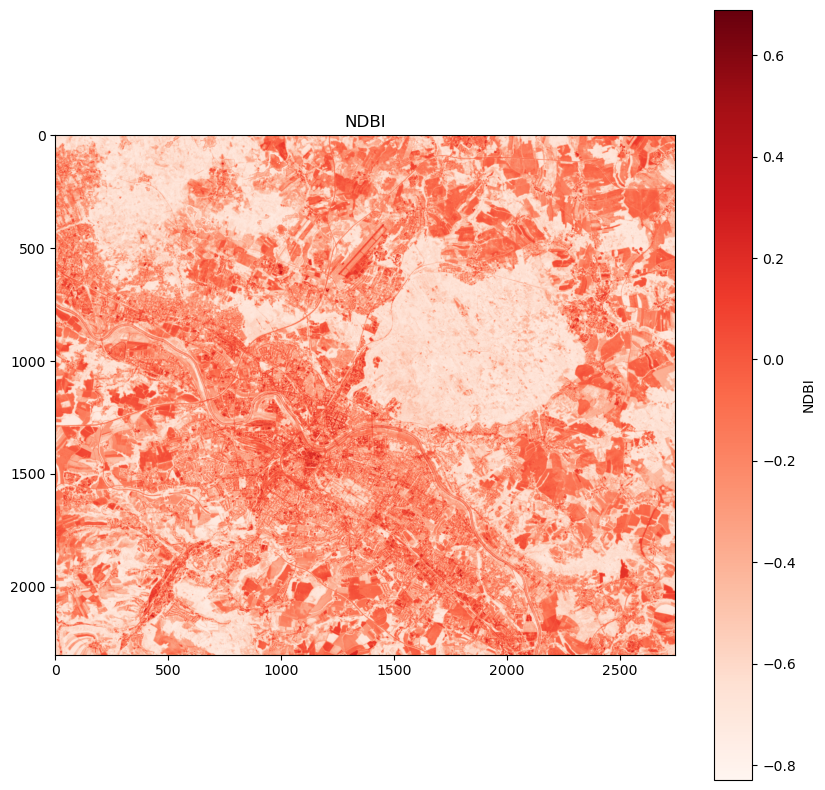

In [25]:
swir = processed_sat_img.sel(band=12)

# Calculate NDBI
ndbi = (swir - nir) / (swir + nir)
ndbi = ndbi.expand_dims('band').assign_coords(band=[18])

print(ndbi.max(), ndbi.min())

# Plot the NDBI
plt.figure(figsize=(10, 10))
plt.imshow(ndbi.sel(band=18), cmap='Reds')
plt.colorbar(label='NDBI')
plt.title('NDBI')
plt.show()

# Stack Sentinel-2 image and indices in one file

In [26]:
stacked_img = xr.concat([processed_sat_img, binary_mask_pugs, sdt_pugs, ndvi, ndwi, ndbi], dim='band')

In [27]:
output_path = '../data/processed/sentinel-2/stacked_sentinel2_dresden.geotiff'

In [28]:
try:
   os.makedirs("../data/processed/sentinel-2")
except FileExistsError:
   # Directory already exists
   pass

stacked_img.rio.to_raster(
    output_path,
    driver="GTiff",
    dtype="float32"
)

# Open the saved file

In [29]:
file_path = '../data/processed/sentinel-2/stacked_sentinel2_dresden.geotiff'
data = rioxarray.open_rasterio(file_path)

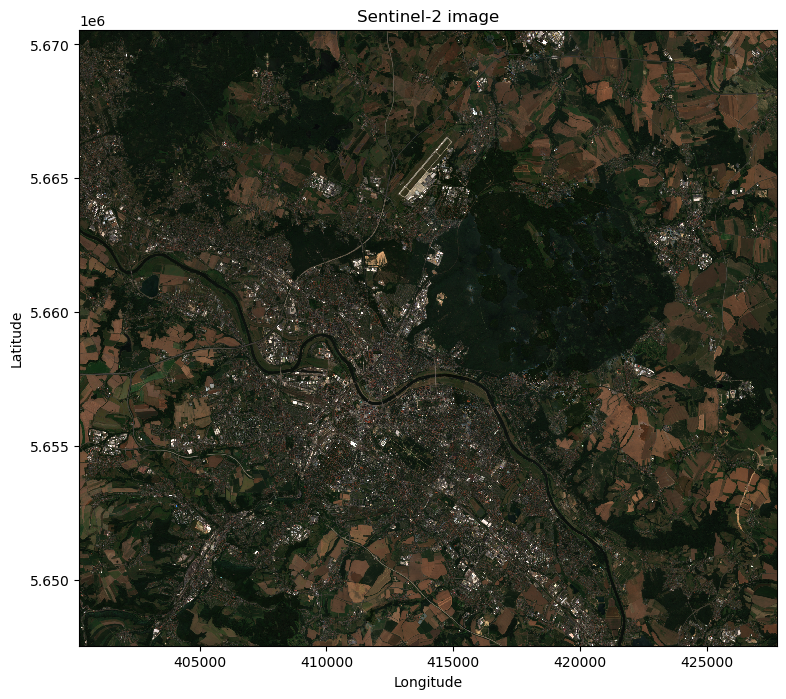

In [30]:
# Plot the raster data
plt.figure(figsize=(9,8))
data.sel(band=[4, 3, 2]).plot.imshow()
plt.title("Sentinel-2 image")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

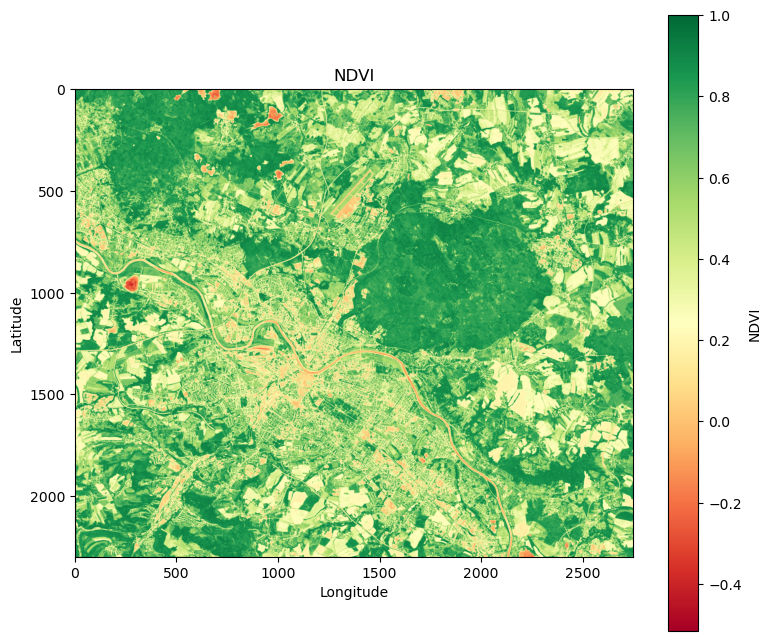

In [31]:
# Plot the raster data
plt.figure(figsize=(9,8))
plt.imshow(data.sel(band=16), cmap='RdYlGn')
plt.title("NDVI")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label='NDVI')
plt.show()

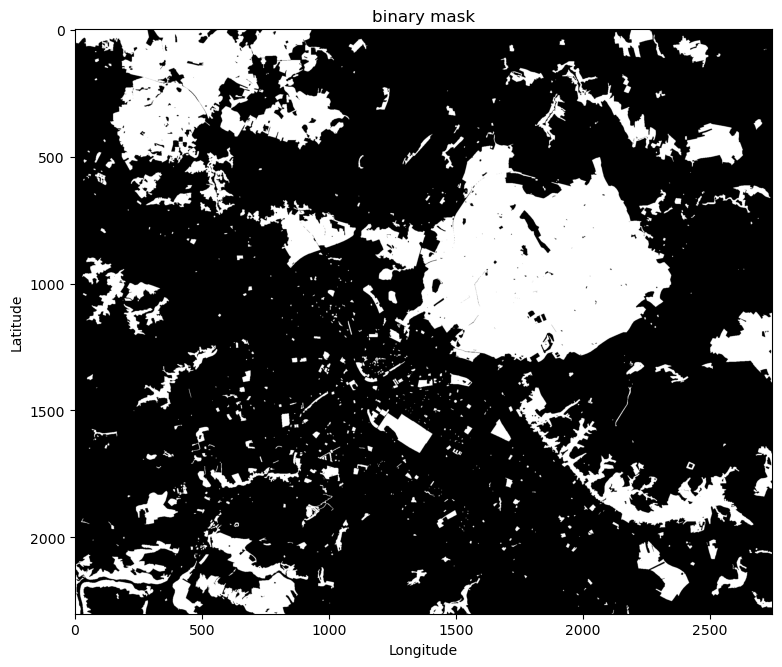

In [ ]:
# Plot the raster data
plt.figure(figsize=(9,8))
plt.imshow(data.sel(band=14), cmap='gray')
plt.title("binary mask")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()